# Неделя 4. Понедельник

## Обучение без учителя


### Кластеризация

### Задание 1

Импортируйте несколько моделей кластеризации: 
* KMeans
* DBSCAN
* https://scikit-learn.org/stable/modules/clustering.html

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from umap import UMAP
import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import sklearn

sklearn.set_config(transform_output="pandas")
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    homogeneity_score,
    completeness_score,
    silhouette_score,
    rand_score,
)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

Импортируй датасет: `path = 'aux/X_train.txt'`

* В этом файле содержатся датчики мобильного телефона для различных активностей пользователя. Необходимо выявить какие кластеры можно выделить в данных и предположить, каким состояниями они соответствуют (пользователь в покое, идет, сидит и тд.)

* Фичей много, и здесь не особо нужно, что каждая из них значит, однако более детально об эксперименте можно прочитать [тут](https://data.world/uci/human-activity-recognition)

In [54]:
path = "data/X_train.txt"
X_train = pd.read_csv(path, sep="\s+", header=None)

1. Примени ряд кластеризационных [моделей](https://scikit-learn.org/stable/modules/clustering.html) на импортированном датасете.

In [55]:
dbs = DBSCAN(eps=2)
km = KMeans(n_clusters=3, n_init=25, random_state=42, max_iter=500)
agg = AgglomerativeClustering(3)

In [56]:
# km.fit(X_train)

In [57]:
dbs.fit(X_train)

,eps,2
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [74]:
agg.fit(X_train)

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


2. Определи и зафиксируй количество кластеров, которое наиболее оптимально с точки зрения метрики `silhouette`. Установи библиотеку [`yellowbrick`](https://www.scikit-yb.org/en/latest/api/cluster/silhouette.html) и визуализируй результаты для использованных методов (при использовании метода K-means). 

In [59]:
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

##### KMeans

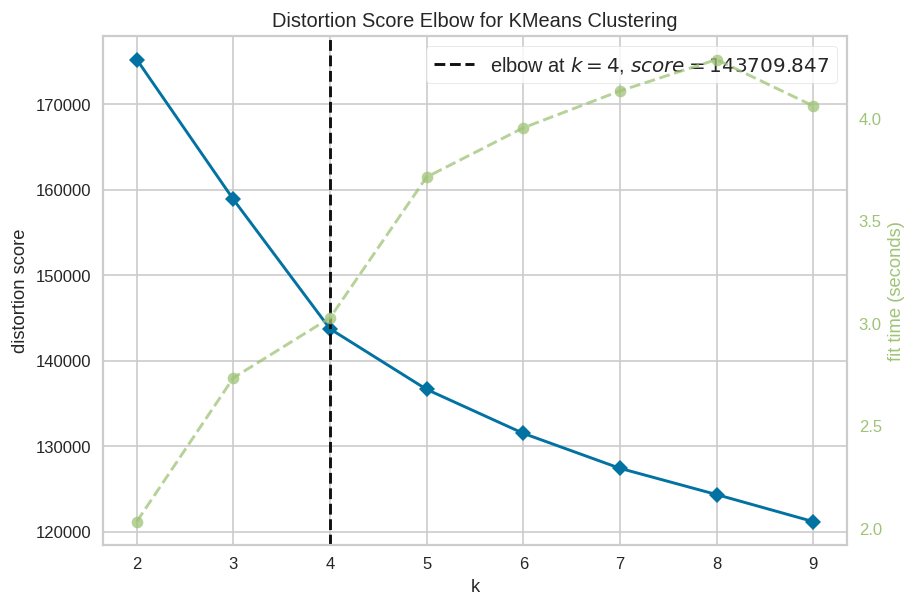

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [60]:
visualizer = KElbowVisualizer(km, k=(2, 10))
visualizer.fit(X_train)
visualizer.show()

In [61]:
km = KMeans(n_clusters=3, n_init=25, random_state=42, max_iter=500)
km.fit(X_train)

,n_clusters,3
,init,'k-means++'
,n_init,25
,max_iter,500
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


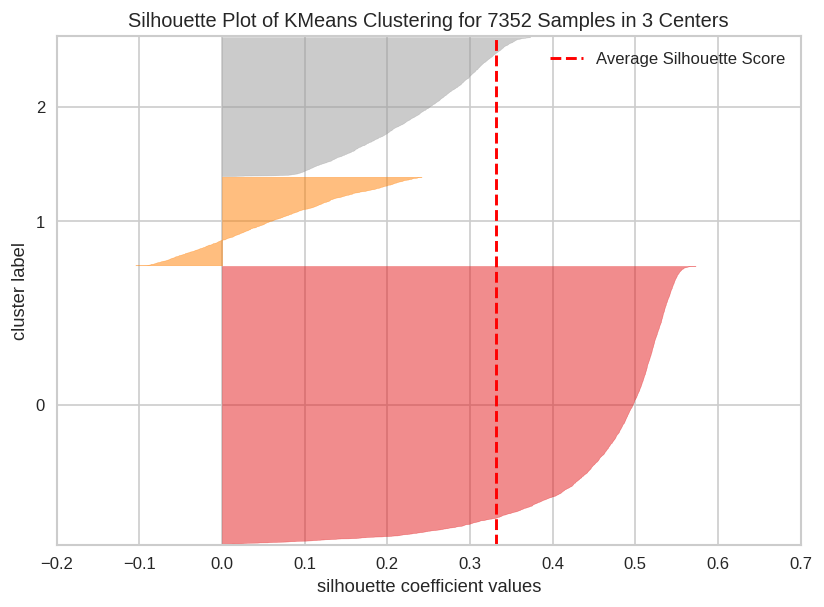

''

In [62]:
visualizer_km = SilhouetteVisualizer(km)
visualizer_km.fit(X_train)
visualizer_km.show()
;

# ❓

Почему метрика `silhouette` может быть бессмысленной в некоторых случаях? Приведи пример такой ситуации. 

> ответ тут

4. Примените [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [UMAP](https://umap-learn.readthedocs.io/en/latest/) и [tSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) декомпозиции и визуализируйте полученные объекты в новом (двумерном или трехмерном) пространстве. В процессе перебирайте возможные параметры и сравнивайте результат по визуализациям.

In [63]:
pca = PCA(n_components=2)
tsne = TSNE(n_components=2, perplexity=30)
ump = umap.UMAP(n_components=2, n_neighbors=100)

In [64]:
X_pca = pca.fit_transform(X_train)
X_tsne = tsne.fit_transform(X_train)
X_umap = ump.fit_transform(X_train)

Text(0.5, 1.0, 'UMAP')

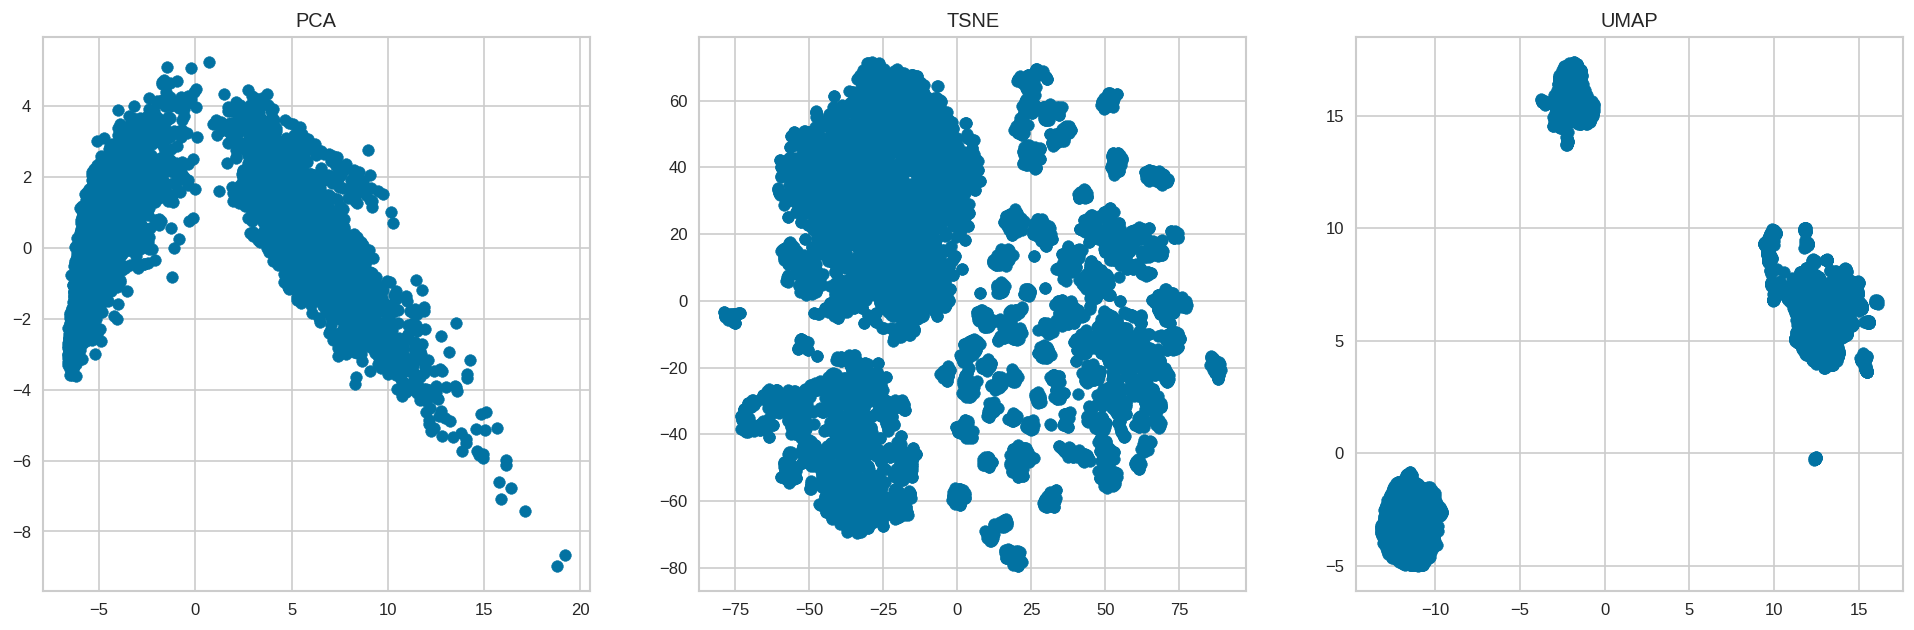

In [65]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.scatter(X_pca.iloc[:, 0], X_pca.iloc[:, 1])
ax2.scatter(X_tsne.iloc[:, 0], X_tsne.iloc[:, 1])
ax3.scatter(X_umap[:, 0], X_umap[:, 1])

ax1.set_title("PCA")
ax2.set_title("TSNE")
ax3.set_title("UMAP")

5. Повтори шаги 1 и 2 для трансформированных данных. 

In [66]:
# dbs1 = DBSCAN(eps=1)
# km1 = KMeans(n_clusters=4, n_init=25, random_state=42, max_iter=500)
# agg1 = AgglomerativeClustering()

In [96]:
X = {"pca": X_pca, "tsne": X_tsne, "umap": X_umap}

models = {
    "KMeans": KMeans(n_clusters=5, n_init=25, random_state=42, max_iter=500),
    "AggCls": AgglomerativeClustering(5),
    "DBSCAN": DBSCAN(eps=1),
}

In [97]:
def plot_results(X: dict, models: dict):
    fig, ax = plt.subplots(3, 3, figsize=(12, 12))
    for i in np.arange(3):
        for j in np.arange(3):
            X_ = list(X.values())[i]
            model = list(models.values())[j].fit(X_)
            colors = model.labels_
            sil_score = silhouette_score(X_, model.labels_)
            #
            ax[i, j].scatter(
                np.array(X_)[:, 0],
                np.array(X_)[:, 1],
                c=colors,
                marker=".",
                s=10,
                cmap="rainbow",
            )
            ax[i, j].set_title(
                f"{list(X.keys())[i]}/{list(models.keys())[j]}: sil_score={sil_score:.3f}"
            )

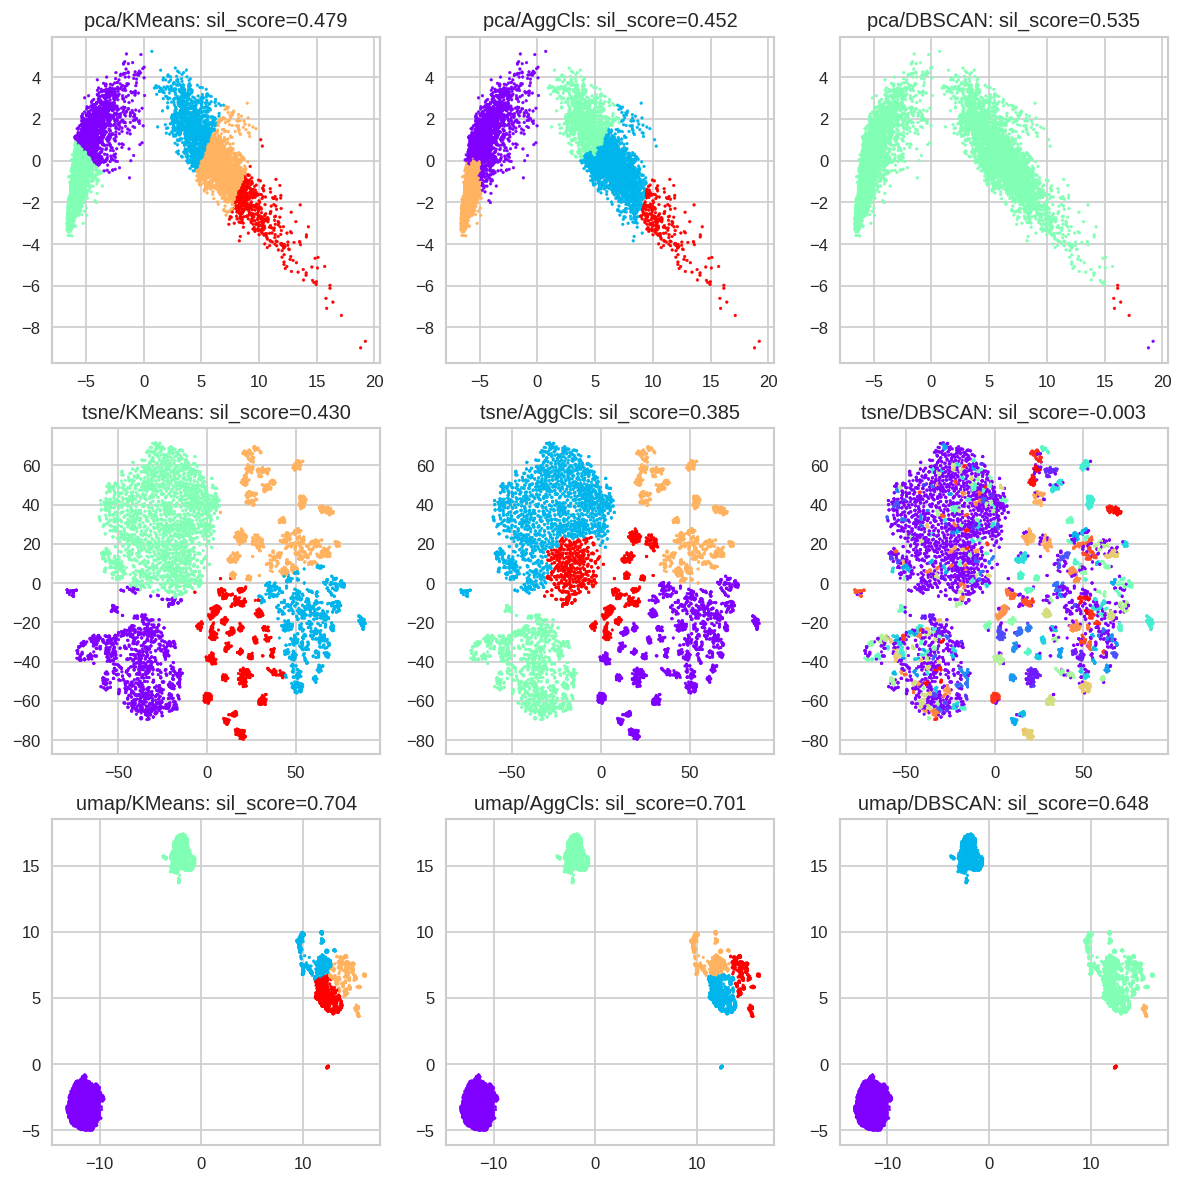

In [98]:
plot_results(X, models)

6. Сделай вывод: какой метод кластеризации и какие преобразования данных дают наилучший результат в контексте метрики силует. 

> Лучшую метрику силуэт дает комбинация UMAP + KMeans/AggCls

7. Визуализируй наиболее успешный результат, цветос выдели кластеры

In [70]:
# code

8. Теперь настало время внешних метрик.

* Подгрузи файл `y_train.txt`. В нем разметка реальных активностей человека, [здесь](https://data.world/uci/human-activity-recognition) можно найти какой класс - какая активность.
* Посчитай внешние метрики $homogenity$ и $completeness$.
* Выбери оптимальное количество кластеров в контексте внешних метрик

In [71]:
path2 = "data/y_train.txt"

In [ ]:
y_train = pd.read_csv(path2, sep="\s+", header=None)

,0
0,5
1,5
2,5
3,5
4,5
...,...
7347,2
7348,2
7349,2
7350,2


In [89]:
dbs1 = DBSCAN(eps=1)
km1 = KMeans(n_clusters=5, n_init=25, random_state=42, max_iter=500)
agg1 = AgglomerativeClustering(5)

In [90]:
dbs1.fit(X_umap)
km1.fit(X_umap)
agg1.fit(X_umap)

,n_clusters,5
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [91]:
metrics_umap = pd.DataFrame(
    data={
        "homogenity": [
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(km1.labels_)),
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(agg1.labels_)),
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(dbs1.labels_)),
        ],
        "completeness": [
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(km1.labels_)),
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(agg1.labels_)),
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(dbs1.labels_)),
        ],
    },
    index=["KMeans", "AggCls", "DBSCAN"],
)
metrics_umap

,homogenity,completeness
KMeans,0.709282,0.824220
AggCls,0.718618,0.837332
DBSCAN,0.592646,0.920326


In [92]:
dbs1.fit(X_pca)
km1.fit(X_pca)
agg1.fit(X_pca)

,n_clusters,5
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [93]:
metrics_pca = pd.DataFrame(
    data={
        "homogenity": [
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(km1.labels_)),
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(agg1.labels_)),
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(dbs1.labels_)),
        ],
        "completeness": [
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(km1.labels_)),
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(agg1.labels_)),
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(dbs1.labels_)),
        ],
    },
    index=["KMeans", "AggCls", "DBSCAN"],
)
metrics_pca

,homogenity,completeness
KMeans,0.420303,0.498880
AggCls,0.423761,0.513856
DBSCAN,0.001228,0.240021


In [94]:
dbs1.fit(X_tsne)
km1.fit(X_tsne)
agg1.fit(X_tsne)

,n_clusters,5
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [95]:
metrics_tsne = pd.DataFrame(
    data={
        "homogenity": [
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(km1.labels_)),
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(agg1.labels_)),
            homogeneity_score(np.array(y_train.iloc[:, 0]), np.array(dbs1.labels_)),
        ],
        "completeness": [
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(km1.labels_)),
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(agg1.labels_)),
            completeness_score(np.array(y_train.iloc[:, 0]), np.array(dbs1.labels_)),
        ],
    },
    index=["KMeans", "AggCls", "DBSCAN"],
)
metrics_tsne

,homogenity,completeness
KMeans,0.707688,0.819460
AggCls,0.623954,0.707914
DBSCAN,0.649980,0.280916


<img src="https://icons.iconarchive.com/icons/icons8/windows-8/256/Programming-Github-icon.png" width=32 /> Пора закоммить изменения в файле. Сделай это с сообщением: 
`"Clustering: task 1 finished"`

После коммита выполни `!git status` в ячейке ниже. 

In [ ]:
# code

### Задание 2

Скачай с kaggle [датасет](https://www.kaggle.com/arjunbhasin2013/ccdata) с информацией об обладателях кредитных карт. Кластеризируй объекты и проанализируй результат. 

In [ ]:
# code

<img src="https://icons.iconarchive.com/icons/icons8/windows-8/256/Programming-Github-icon.png" width=32 /> Сделай пуш на __github__. 